In [1]:

import os, time, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception as e:
            print("Memory growth not set:", e)
else:
    print("WARNING: No GPU detected. Go to Kaggle Settings -> Accelerator -> GPU.")

# Mixed precision speeds things up considerably on T4/P100 GPUs
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled:", mixed_precision.global_policy())
except Exception as e:
    print("Mixed precision not enabled:", e)


TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision enabled: <DTypePolicy "mixed_float16">


In [2]:

CONFIG = {
    # Data
    "NUM_CLASSES": 10,
    "VAL_SPLIT": 0.1,
    "TL_IMG_SIZE": 96,       # resize target for transfer-learning backbones (>=32 required by Keras apps; 96 balances accuracy/speed)
    "BASELINE_IMG_SIZE": 32, # native CIFAR-10 size for from-scratch baselines
    "BATCH_SIZE": 64,

    # Baseline (from-scratch) training
    "EPOCHS_BASELINE": 12,

    # Transfer learning
    "EPOCHS_FROZEN": 8,      # Task 3
    "EPOCHS_FINETUNE": 6,    # Task 4
    "LR_FROZEN": 1e-3,
    "LR_FINETUNE": 1e-5,

    # Additional-exercise light runs (kept short to save GPU time; raise if you have quota)
    "EPOCHS_OPTIM_COMPARE": 5,
    "EPOCHS_HPARAM_SEARCH": 4,
}

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

AUTOTUNE = tf.data.AUTOTUNE
print(CONFIG)


{'NUM_CLASSES': 10, 'VAL_SPLIT': 0.1, 'TL_IMG_SIZE': 96, 'BASELINE_IMG_SIZE': 32, 'BATCH_SIZE': 64, 'EPOCHS_BASELINE': 12, 'EPOCHS_FROZEN': 8, 'EPOCHS_FINETUNE': 6, 'LR_FROZEN': 0.001, 'LR_FINETUNE': 1e-05, 'EPOCHS_OPTIM_COMPARE': 5, 'EPOCHS_HPARAM_SEARCH': 4}


In [3]:

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

y_train_full = y_train_full.squeeze()
y_test = y_test.squeeze()

# Normalize pixel values to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Train / validation split
val_count = int(len(x_train_full) * CONFIG["VAL_SPLIT"])
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(x_train_full))
val_idx, train_idx = perm[:val_count], perm[val_count:]

x_train, y_train = x_train_full[train_idx], y_train_full[train_idx]
x_val, y_val = x_train_full[val_idx], y_train_full[val_idx]

print("Training set   :", x_train.shape, y_train.shape)
print("Validation set  :", x_val.shape, y_val.shape)
print("Testing set     :", x_test.shape, y_test.shape)
print("Pixel value range: [{:.3f}, {:.3f}]".format(x_train.min(), x_train.max()))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2129s 12us/step
Training set   : (45000, 32, 32, 3) (45000,)
Validation set  : (5000, 32, 32, 3) (5000,)
Testing set     : (10000, 32, 32, 3) (10000,)
Pixel value range: [0.000, 1.000]


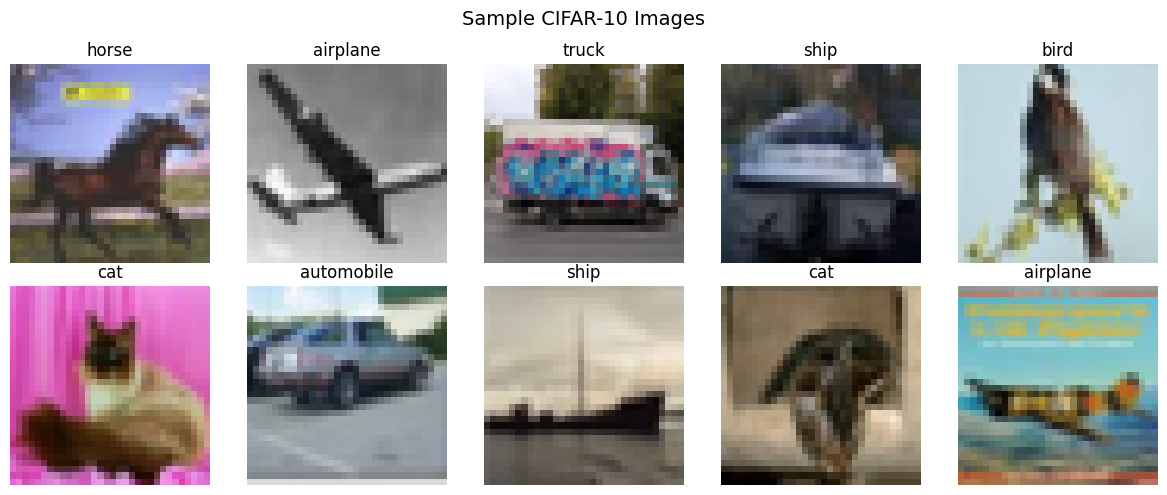

In [4]:

# Display ten sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i]])
    ax.axis("off")
plt.suptitle("Sample CIFAR-10 Images", fontsize=14)
plt.tight_layout()
plt.savefig("fig_sample_images.png", dpi=120)
plt.show()


In [5]:

def make_baseline_ds(x, y, training=False, batch_size=None):
    batch_size = batch_size or CONFIG["BATCH_SIZE"]
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10000, seed=SEED)
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomTranslation(0.1, 0.1),
        ])
        ds = ds.map(lambda img, lbl: (aug(img, training=True), lbl), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    return ds.prefetch(AUTOTUNE)

ds_train_base = make_baseline_ds(x_train, y_train, training=True)
ds_val_base   = make_baseline_ds(x_val, y_val, training=False)
ds_test_base  = make_baseline_ds(x_test, y_test, training=False)

print("Baseline pipelines ready.")


I0000 00:00:1787733122.018416      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787733122.021701      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Baseline pipelines ready.


In [6]:

def make_tl_ds(x, y, preprocess_fn, img_size, training=False, batch_size=None):
    # Resize CIFAR images (currently in [0,1] float) to img_size, rescale back to
    # [0,255] and apply the backbone-specific preprocess_input, then batch/prefetch.
    batch_size = batch_size or CONFIG["BATCH_SIZE"]
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10000, seed=SEED)

    def _prep(img, lbl):
        img = tf.image.resize(img, (img_size, img_size), method="bilinear")
        img = img * 255.0
        if training:
            img = tf.image.random_flip_left_right(img)
        img = preprocess_fn(img)
        return img, lbl

    ds = ds.map(_prep, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    return ds.prefetch(AUTOTUNE)

print("Transfer-learning pipeline builder ready.")


Transfer-learning pipeline builder ready.


In [7]:

def build_lenet5(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(6, 5, activation="tanh", padding="same")(inputs)
    x = layers.AveragePooling2D(2)(x)
    x = layers.Conv2D(16, 5, activation="tanh")(x)
    x = layers.AveragePooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(120, activation="tanh")(x)
    x = layers.Dense(84, activation="tanh")(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    return keras.Model(inputs, outputs, name="LeNet5")


def build_alexnet_mini(input_shape=(32, 32, 3), num_classes=10):
    # AlexNet's core ideas (ReLU, Dropout, stacked conv blocks) scaled to 32x32 input.
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(192, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(384, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(1024, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    return keras.Model(inputs, outputs, name="AlexNetMini")


def _residual_block(x, filters, downsample=False):
    stride = 2 if downsample else 1
    shortcut = x
    y = layers.Conv2D(filters, 3, strides=stride, padding="same")(x)
    y = layers.BatchNormalization()(y)
    y = layers.ReLU()(y)
    y = layers.Conv2D(filters, 3, strides=1, padding="same")(y)
    y = layers.BatchNormalization()(y)
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    out = layers.Add()([y, shortcut])
    return layers.ReLU()(out)


def build_resnet_mini(input_shape=(32, 32, 3), num_classes=10):
    # A compact ResNet built from residual (skip-connection) blocks, illustrating
    # F(x) = H(x) - x  =>  Output = F(x) + x  as described in the manual.
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = _residual_block(x, 32)
    x = _residual_block(x, 64, downsample=True)
    x = _residual_block(x, 64)
    x = _residual_block(x, 128, downsample=True)
    x = _residual_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    return keras.Model(inputs, outputs, name="ResNetMini")


for builder in (build_lenet5, build_alexnet_mini, build_resnet_mini):
    m = builder()
    print(f"{m.name}: {m.count_params():,} parameters")


LeNet5: 83,126 parameters
AlexNetMini: 6,976,842 parameters
ResNetMini: 681,226 parameters


In [8]:

def compile_model(model, optimizer="adam", lr=1e-3):
    if optimizer.lower() == "adam":
        opt = optimizers.Adam(learning_rate=lr)
    elif optimizer.lower() == "sgd":
        opt = optimizers.SGD(learning_rate=lr, momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer}")
    model.compile(optimizer=opt,
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])
    return model


def train_model(model, train_ds, val_ds, epochs, callbacks=None):
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                         callbacks=callbacks or [], verbose=1)
    elapsed = time.time() - start
    return history, elapsed


def evaluate_model(model, test_ds, y_true, class_names=CLASS_NAMES, title="Model"):
    y_prob = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n=== {title}: Test Set Evaluation ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(f"Confusion Matrix — {title}")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
    fig.colorbar(im)
    plt.tight_layout()
    safe_title = title.lower().replace(" ", "_")
    plt.savefig(f"fig_confmat_{safe_title}.png", dpi=120)
    plt.show()

    return {"model": title, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
            "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob}


def plot_history(history, title="Model"):
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist["accuracy"], label="Train Accuracy")
    axes[0].plot(hist["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"{title} — Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(hist["loss"], label="Train Loss")
    axes[1].plot(hist["val_loss"], label="Validation Loss")
    axes[1].set_title(f"{title} — Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    plt.tight_layout()
    safe_title = title.lower().replace(" ", "_")
    plt.savefig(f"fig_history_{safe_title}.png", dpi=120)
    plt.show()

print("Helper functions ready.")


Helper functions ready.


Epoch 1/12
  9/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.1004 - loss: 2.3940

I0000 00:00:1787733146.459928      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step - accuracy: 0.3388 - loss: 1.8597 - val_accuracy: 0.4080 - val_loss: 1.7064
Epoch 2/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.4012 - loss: 1.6807 - val_accuracy: 0.4470 - val_loss: 1.5671
Epoch 3/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.4435 - loss: 1.5577 - val_accuracy: 0.4546 - val_loss: 1.5170
Epoch 4/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.4667 - loss: 1.4918 - val_accuracy: 0.4910 - val_loss: 1.4320
Epoch 5/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.4830 - loss: 1.4517 - val_accuracy: 0.5122 - val_loss: 1.4055
Epoch 6/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.4965 - loss: 1.4223 - val_accuracy: 0.5174 - val_loss: 1.3643
Epoch 7/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.5086 - loss: 1.3842 - val_accuracy: 0.5284 - val_loss: 1.3568
Epoch 8/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.5169 - loss: 1.3587 - val_accurac

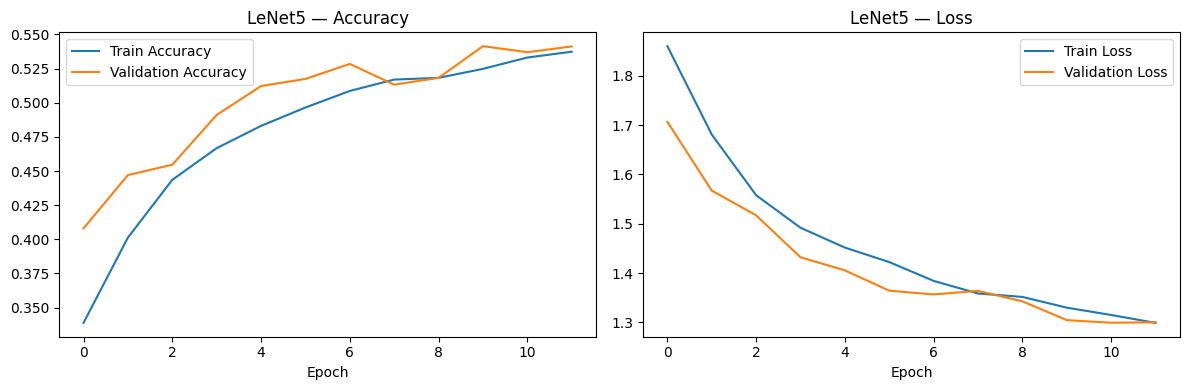


=== LeNet5: Test Set Evaluation ===
Accuracy : 0.5426
Precision: 0.5481
Recall   : 0.5426
F1-score : 0.5403

Classification Report:
               precision    recall  f1-score   support

    airplane       0.53      0.69      0.60      1000
  automobile       0.68      0.63      0.65      1000
        bird       0.43      0.48      0.45      1000
         cat       0.37      0.32      0.34      1000
        deer       0.59      0.35      0.44      1000
         dog       0.42      0.52      0.47      1000
        frog       0.60      0.59      0.60      1000
       horse       0.58      0.60      0.59      1000
        ship       0.67      0.64      0.65      1000
       truck       0.61      0.60      0.61      1000

    accuracy                           0.54     10000
   macro avg       0.55      0.54      0.54     10000
weighted avg       0.55      0.54      0.54     10000



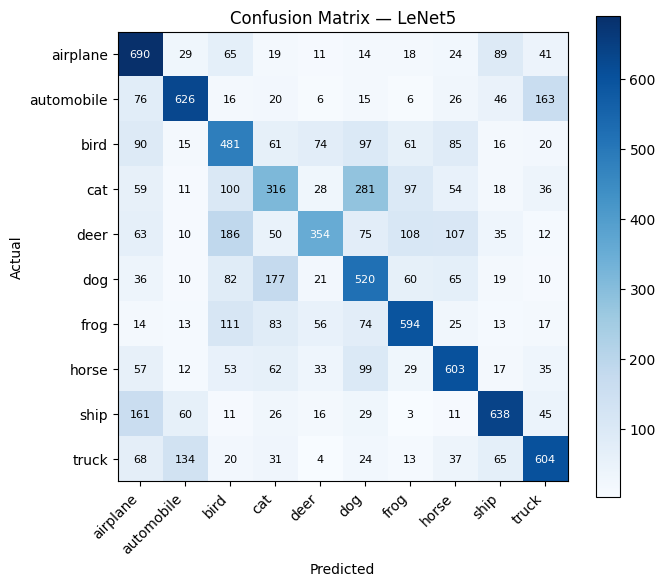

Epoch 1/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 46ms/step - accuracy: 0.3008 - loss: 1.8320 - val_accuracy: 0.4546 - val_loss: 1.4601
Epoch 2/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.4923 - loss: 1.3917 - val_accuracy: 0.5466 - val_loss: 1.2487
Epoch 3/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.5700 - loss: 1.1971 - val_accuracy: 0.5962 - val_loss: 1.1114
Epoch 4/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.6147 - loss: 1.0894 - val_accuracy: 0.6554 - val_loss: 0.9461
Epoch 5/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.6527 - loss: 0.9951 - val_accuracy: 0.6906 - val_loss: 0.8435
Epoch 6/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.6784 - loss: 0.9281 - val_accuracy: 0.6924 - val_loss: 0.8992
Epoch 7/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.6940 - loss: 0.8842 - val_accuracy: 0.7082 - val_loss: 0.8209
Epoch 8/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.7091 - loss: 0.8449 - 

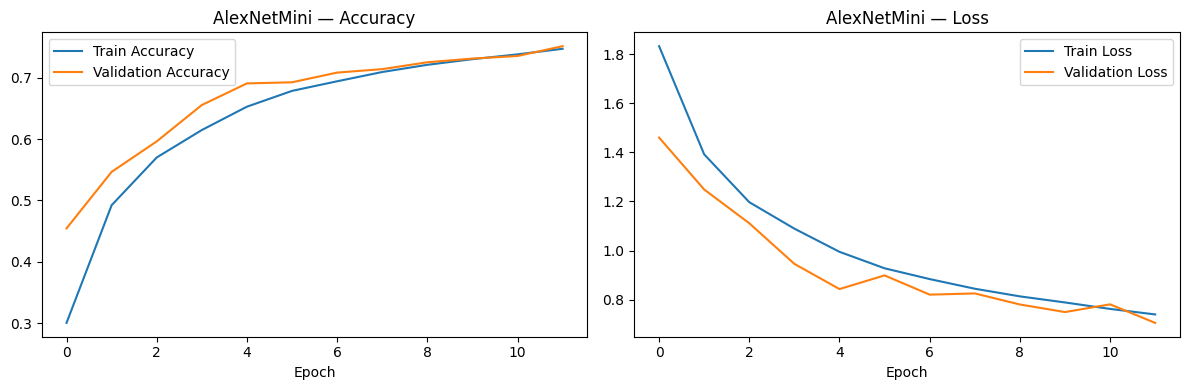


=== AlexNetMini: Test Set Evaluation ===
Accuracy : 0.7526
Precision: 0.7575
Recall   : 0.7526
F1-score : 0.7486

Classification Report:
               precision    recall  f1-score   support

    airplane       0.79      0.79      0.79      1000
  automobile       0.84      0.94      0.89      1000
        bird       0.73      0.56      0.64      1000
         cat       0.63      0.52      0.57      1000
        deer       0.70      0.74      0.72      1000
         dog       0.73      0.59      0.65      1000
        frog       0.61      0.92      0.73      1000
       horse       0.85      0.75      0.80      1000
        ship       0.85      0.89      0.87      1000
       truck       0.85      0.82      0.83      1000

    accuracy                           0.75     10000
   macro avg       0.76      0.75      0.75     10000
weighted avg       0.76      0.75      0.75     10000



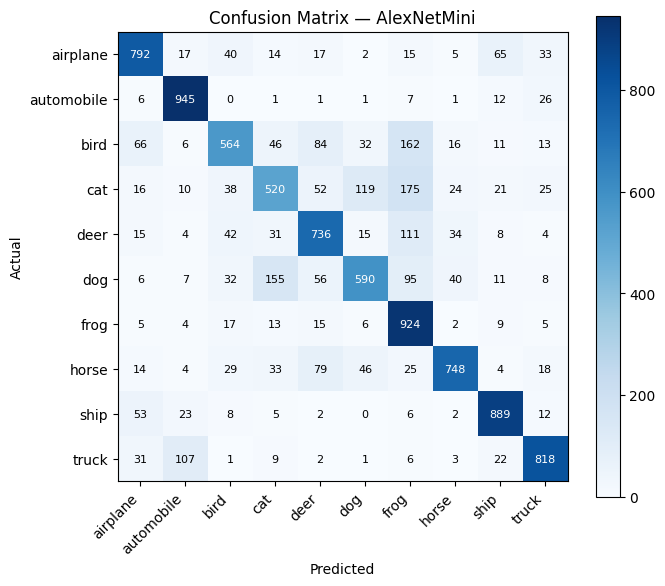

Epoch 1/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 62ms/step - accuracy: 0.4544 - loss: 1.5090 - val_accuracy: 0.4824 - val_loss: 1.7096
Epoch 2/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.6284 - loss: 1.0487 - val_accuracy: 0.5416 - val_loss: 1.5178
Epoch 3/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.6994 - loss: 0.8663 - val_accuracy: 0.6174 - val_loss: 1.0841
Epoch 4/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.7440 - loss: 0.7392 - val_accuracy: 0.6942 - val_loss: 0.8715


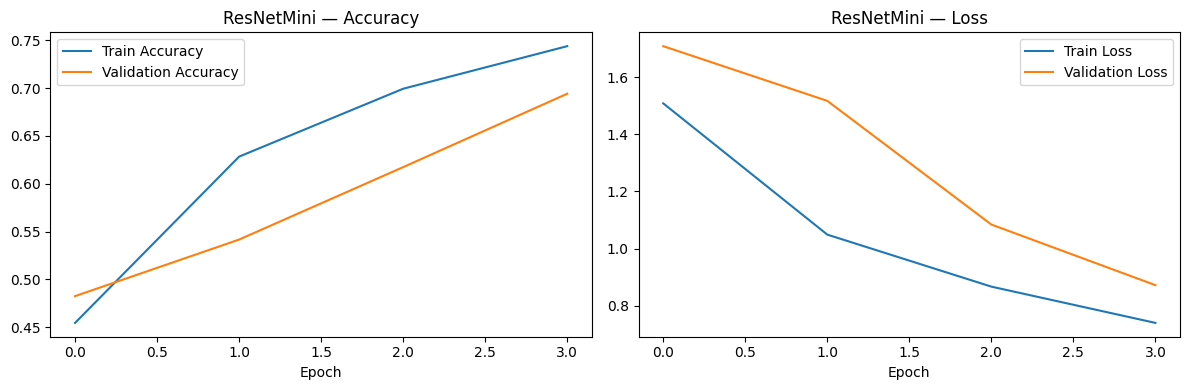


=== ResNetMini: Test Set Evaluation ===
Accuracy : 0.4726
Precision: 0.5552
Recall   : 0.4726
F1-score : 0.4317

Classification Report:
               precision    recall  f1-score   support

    airplane       0.45      0.56      0.50      1000
  automobile       0.43      0.86      0.58      1000
        bird       0.35      0.48      0.41      1000
         cat       0.41      0.32      0.36      1000
        deer       0.63      0.16      0.26      1000
         dog       0.51      0.24      0.33      1000
        frog       0.41      0.79      0.54      1000
       horse       0.82      0.48      0.61      1000
        ship       0.59      0.79      0.67      1000
       truck       0.94      0.03      0.06      1000

    accuracy                           0.47     10000
   macro avg       0.56      0.47      0.43     10000
weighted avg       0.56      0.47      0.43     10000



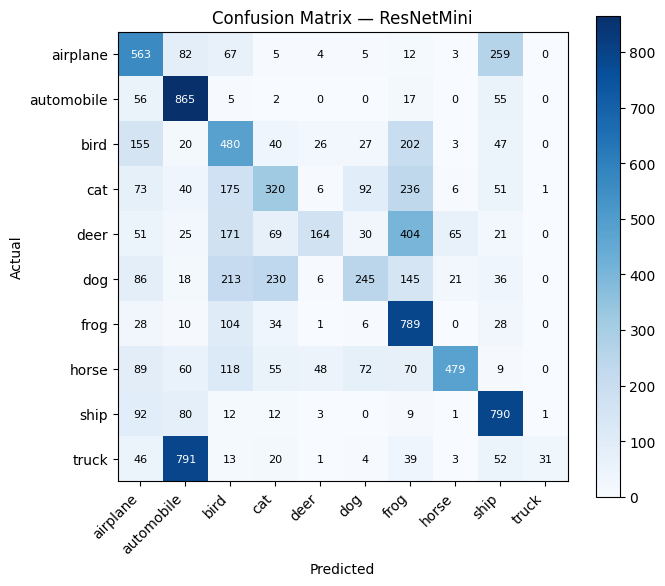

Baseline training complete for: ['LeNet5', 'AlexNetMini', 'ResNetMini']


In [9]:

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)

baseline_results = []
baseline_histories = {}
baseline_models = {}

for builder in (build_lenet5, build_alexnet_mini, build_resnet_mini):
    model = builder()
    compile_model(model, optimizer="adam", lr=1e-3)
    hist, elapsed = train_model(model, ds_train_base, ds_val_base,
                                 epochs=CONFIG["EPOCHS_BASELINE"], callbacks=[early_stop])
    baseline_histories[model.name] = hist
    baseline_models[model.name] = model
    plot_history(hist, title=model.name)
    res = evaluate_model(model, ds_test_base, y_test, title=model.name)
    res["params"] = model.count_params()
    res["train_time_sec"] = elapsed
    baseline_results.append(res)

print("Baseline training complete for:", list(baseline_models.keys()))


In [10]:

baseline_summary = pd.DataFrame([{
    "Model": r["model"], "Parameters": r["params"], "Test Accuracy (%)": round(r["accuracy"] * 100, 2),
    "Precision": round(r["precision"], 4), "Recall": round(r["recall"], 4), "F1-score": round(r["f1"], 4),
    "Training Time (s)": round(r["train_time_sec"], 1)
} for r in baseline_results])

baseline_summary


,Model,Parameters,Test Accuracy (%),Precision,Recall,F1-score,Training Time (s)
0,LeNet5,83126,54.26,0.5481,0.5426,0.5403,232.8
1,AlexNetMini,6976842,75.26,0.7575,0.7526,0.7486,306.1
2,ResNetMini,681226,47.26,0.5552,0.4726,0.4317,141.1


In [11]:

BACKBONE_REGISTRY = {
    "VGG16": (keras.applications.VGG16, keras.applications.vgg16.preprocess_input),
    "ResNet50": (keras.applications.ResNet50, keras.applications.resnet50.preprocess_input),
    "MobileNetV2": (keras.applications.MobileNetV2, keras.applications.mobilenet_v2.preprocess_input),
    "InceptionV3": (keras.applications.InceptionV3, keras.applications.inception_v3.preprocess_input),   # GoogleNet family
    "EfficientNetB0": (keras.applications.EfficientNetB0, keras.applications.efficientnet.preprocess_input),
}


def build_transfer_model(backbone_name, img_size, num_classes=10, dense_units=256, dropout=0.4):
    app_cls, preprocess_fn = BACKBONE_REGISTRY[backbone_name]
    base = app_cls(include_top=False, weights="imagenet",
                    input_shape=(img_size, img_size, 3))
    base.trainable = False  # freeze convolutional base (Task 2, step 3)

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)                      # Task 2, step 4
    x = layers.Dense(dense_units, activation="relu")(x)          # Task 2, step 5
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)  # Task 2, step 6

    model = keras.Model(inputs, outputs, name=f"{backbone_name}_TL")
    return model, base, preprocess_fn


def unfreeze_last_block(base_model, num_layers=20):
    # Unfreeze the last `num_layers` layers of the base model for fine-tuning (Task 4, step 1).
    base_model.trainable = True
    for layer in base_model.layers[:-num_layers]:
        layer.trainable = False
    return base_model

print("Transfer-learning builders ready. Backbones:", list(BACKBONE_REGISTRY.keys()))


Transfer-learning builders ready. Backbones: ['VGG16', 'ResNet50', 'MobileNetV2', 'InceptionV3', 'EfficientNetB0']


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.7061 - loss: 1.0545 - val_accuracy: 0.8144 - val_loss: 0.5512
Epoch 2/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.7952 - loss: 0.6064 - val_accuracy: 0.8224 - val_loss: 0.5091
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8146 - loss: 0.5392 - val_accuracy: 0.8246 - val_loss: 0.5122
Epoch 4/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8295 - loss: 0.4989 - val_accuracy: 0.8362 - val_loss: 0.4914
Epoch 5/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8398 - loss: 0.4661 - val_accuracy: 0.8436 - val_loss: 0.4895
Epoch 6/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8462 - loss: 0.4392 - val_accuracy: 0.8398 - val_loss: 0.4743
Epoch 7/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8555 - loss: 0.4163 - val_accuracy: 0.8372 - val_loss: 0.4717
Epoch 8/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8579 - loss: 0.4069 - val_accu

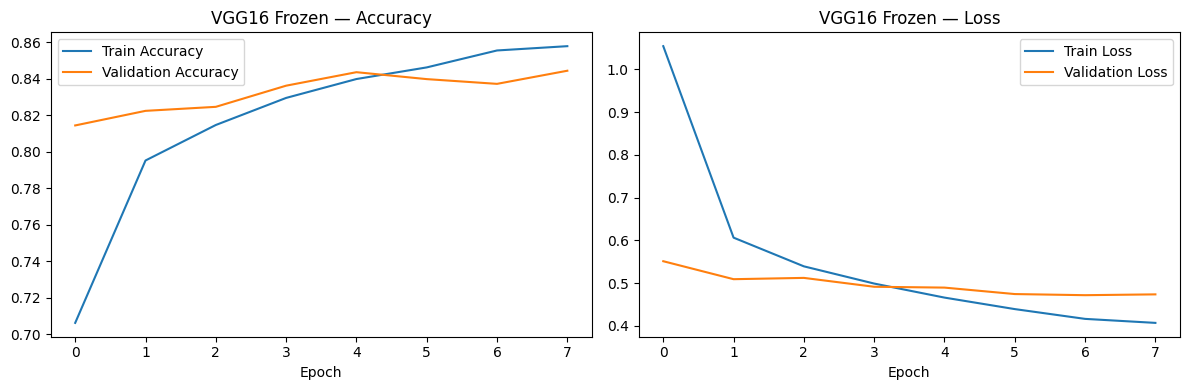


=== VGG16 Frozen: Test Set Evaluation ===
Accuracy : 0.8310
Precision: 0.8323
Recall   : 0.8310
F1-score : 0.8306

Classification Report:
               precision    recall  f1-score   support

    airplane       0.85      0.85      0.85      1000
  automobile       0.92      0.89      0.90      1000
        bird       0.86      0.74      0.79      1000
         cat       0.70      0.71      0.70      1000
        deer       0.76      0.82      0.79      1000
         dog       0.79      0.74      0.77      1000
        frog       0.81      0.91      0.86      1000
       horse       0.86      0.86      0.86      1000
        ship       0.89      0.89      0.89      1000
       truck       0.87      0.91      0.89      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



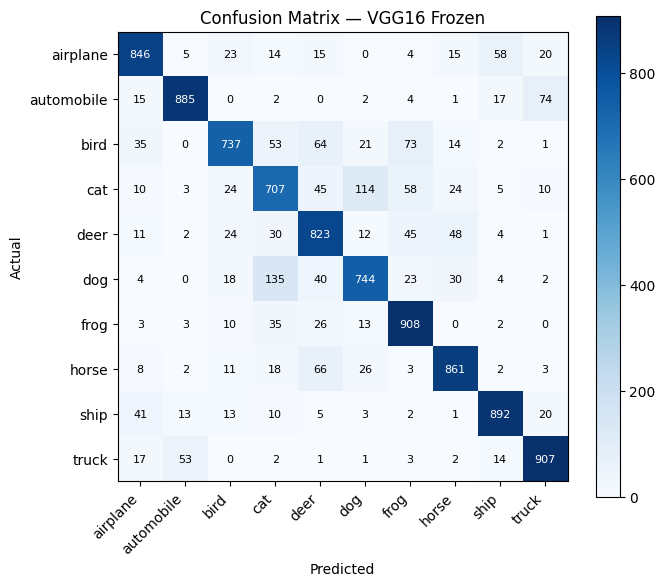

In [12]:

IMG_SIZE = CONFIG["TL_IMG_SIZE"]

vgg_model, vgg_base, vgg_preprocess = build_transfer_model("VGG16", IMG_SIZE)
compile_model(vgg_model, optimizer="adam", lr=CONFIG["LR_FROZEN"])
vgg_model.summary()

ds_train_vgg = make_tl_ds(x_train, y_train, vgg_preprocess, IMG_SIZE, training=True)
ds_val_vgg   = make_tl_ds(x_val, y_val, vgg_preprocess, IMG_SIZE, training=False)
ds_test_vgg  = make_tl_ds(x_test, y_test, vgg_preprocess, IMG_SIZE, training=False)

hist_vgg_frozen, t_vgg_frozen = train_model(vgg_model, ds_train_vgg, ds_val_vgg,
                                             epochs=CONFIG["EPOCHS_FROZEN"], callbacks=[early_stop])
plot_history(hist_vgg_frozen, title="VGG16 Frozen")
res_vgg_frozen = evaluate_model(vgg_model, ds_test_vgg, y_test, title="VGG16 Frozen")
res_vgg_frozen["train_time_sec"] = t_vgg_frozen


Epoch 1/6


2026-08-26 08:46:38.920071: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=0} for conv (f16[512,3,3,512]{3,2,1,0}, u8[0]{0}) custom-call(f16[64,12,12,512]{3,2,1,0}, f16[64,12,12,512]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-08-26 08:46:38.928741: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.008823471s
Trying algorithm eng19{k2=0} for conv (f16[512,3,3,512]{3,2,1,0}, u8[0]{0}) custom-call(f16[64,12,12,512]{3,2,1,0}, f16[64,12,12,512]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"

704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.8863 - loss: 0.3310 - val_accuracy: 0.8774 - val_loss: 0.3724
Epoch 2/6
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9151 - loss: 0.2405 - val_accuracy: 0.8916 - val_loss: 0.3397
Epoch 3/6
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9322 - loss: 0.1906 - val_accuracy: 0.9000 - val_loss: 0.3200
Epoch 4/6
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9470 - loss: 0.1491 - val_accuracy: 0.9100 - val_loss: 0.3137
Epoch 5/6
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9555 - loss: 0.1233 - val_accuracy: 0.9076 - val_loss: 0.3081
Epoch 6/6
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9639 - loss: 0.1021 - val_accuracy: 0.9088 - val_loss: 0.3069


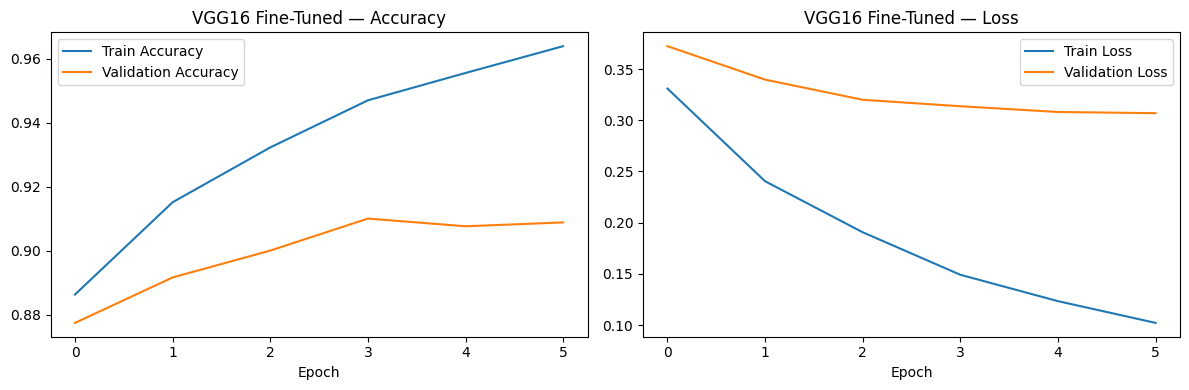


=== VGG16 Fine-Tuned: Test Set Evaluation ===
Accuracy : 0.9026
Precision: 0.9035
Recall   : 0.9026
F1-score : 0.9028

Classification Report:
               precision    recall  f1-score   support

    airplane       0.93      0.91      0.92      1000
  automobile       0.92      0.97      0.94      1000
        bird       0.92      0.88      0.90      1000
         cat       0.80      0.81      0.81      1000
        deer       0.88      0.88      0.88      1000
         dog       0.83      0.86      0.84      1000
        frog       0.94      0.94      0.94      1000
       horse       0.91      0.92      0.91      1000
        ship       0.94      0.96      0.95      1000
       truck       0.97      0.91      0.94      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



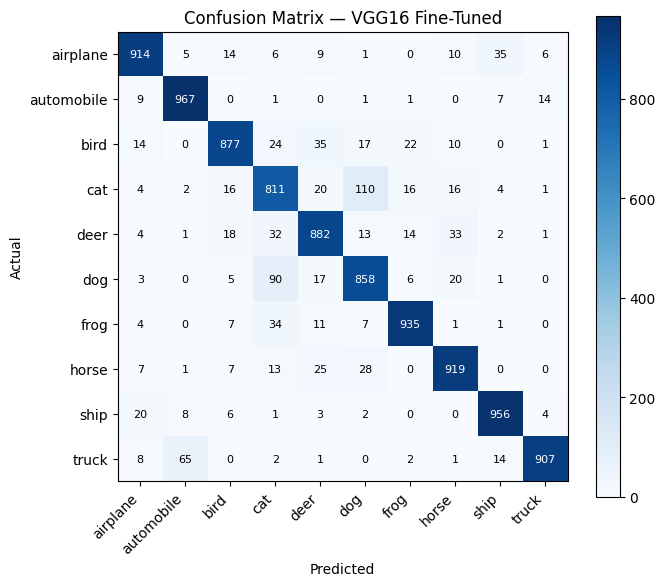


Accuracy before fine-tuning : 83.10%
Accuracy after  fine-tuning : 90.26%


In [13]:

unfreeze_last_block(vgg_base, num_layers=6)   # roughly the last conv block of VGG16
compile_model(vgg_model, optimizer="adam", lr=CONFIG["LR_FINETUNE"])

hist_vgg_ft, t_vgg_ft = train_model(vgg_model, ds_train_vgg, ds_val_vgg,
                                     epochs=CONFIG["EPOCHS_FINETUNE"], callbacks=[early_stop])
plot_history(hist_vgg_ft, title="VGG16 Fine-Tuned")
res_vgg_ft = evaluate_model(vgg_model, ds_test_vgg, y_test, title="VGG16 Fine-Tuned")
res_vgg_ft["train_time_sec"] = t_vgg_ft + t_vgg_frozen

print(f"\nAccuracy before fine-tuning : {res_vgg_frozen['accuracy']*100:.2f}%")
print(f"Accuracy after  fine-tuning : {res_vgg_ft['accuracy']*100:.2f}%")


Misclassified: 974 / 10000 test images


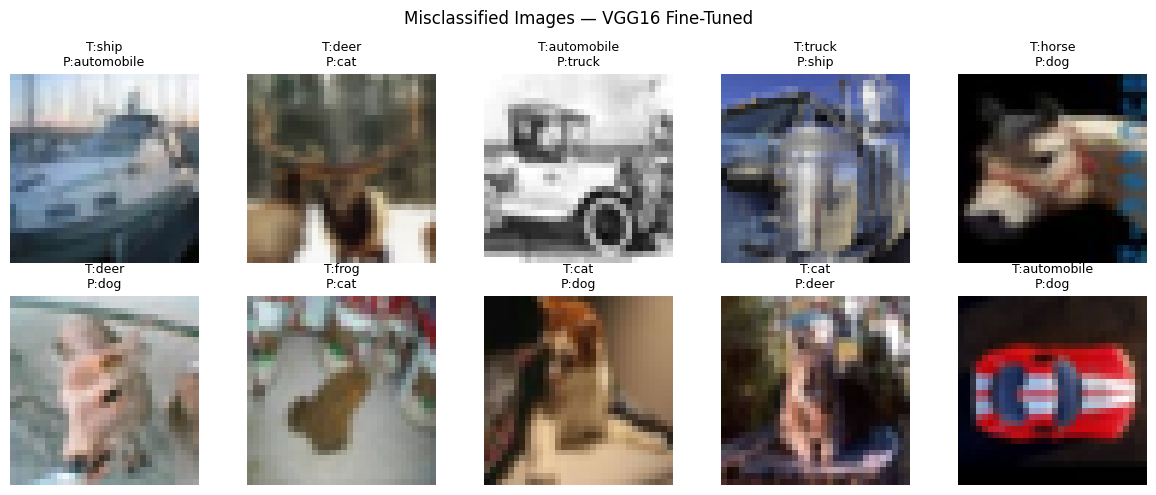

In [14]:

y_pred_vgg = res_vgg_ft["y_pred"]
mis_idx = np.where(y_pred_vgg != y_test)[0]
print(f"Misclassified: {len(mis_idx)} / {len(y_test)} test images")

show_idx = mis_idx[:10] if len(mis_idx) >= 10 else mis_idx
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, show_idx):
    ax.imshow(x_test[idx])
    ax.set_title(f"T:{CLASS_NAMES[y_test[idx]]}\nP:{CLASS_NAMES[y_pred_vgg[idx]]}", fontsize=9)
    ax.axis("off")
for ax in axes.flat[len(show_idx):]:
    ax.axis("off")
plt.suptitle("Misclassified Images — VGG16 Fine-Tuned")
plt.tight_layout()
plt.savefig("fig_misclassified_vgg16.png", dpi=120)
plt.show()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 45ms/step - accuracy: 0.7911 - loss: 0.6337 - val_accuracy: 0.8482 - val_loss: 0.4370
Epoch 2/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8394 - loss: 0.4724 - val_accuracy: 0.8610 - val_loss: 0.4230
Epoch 3/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8546 - loss: 0.4212 - val_accuracy: 0.8636 - val_loss: 0.4065
Epoch 4/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8658 - loss: 0.3899 - val_accuracy: 0.8660 - val_loss: 0.3930


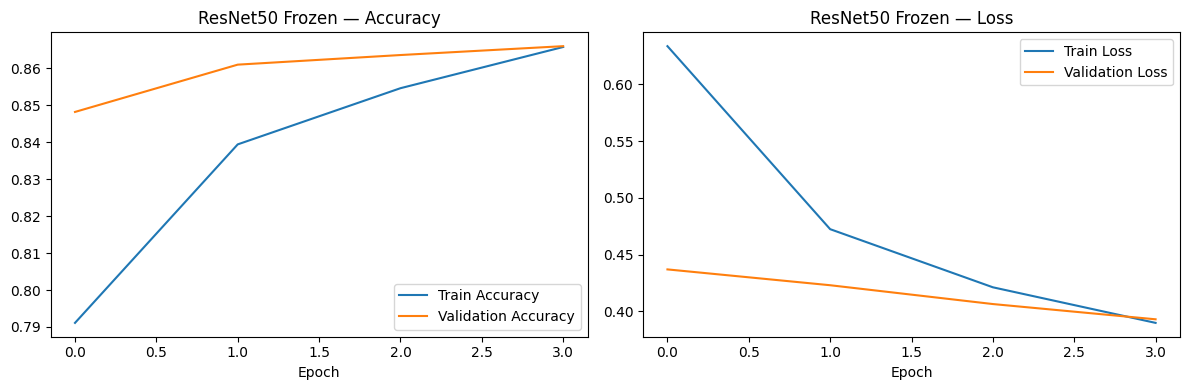


=== ResNet50 Frozen: Test Set Evaluation ===
Accuracy : 0.8441
Precision: 0.8455
Recall   : 0.8441
F1-score : 0.8440

Classification Report:
               precision    recall  f1-score   support

    airplane       0.82      0.89      0.85      1000
  automobile       0.90      0.91      0.90      1000
        bird       0.83      0.82      0.83      1000
         cat       0.74      0.74      0.74      1000
        deer       0.80      0.81      0.80      1000
         dog       0.81      0.79      0.80      1000
        frog       0.89      0.88      0.88      1000
       horse       0.90      0.84      0.87      1000
        ship       0.85      0.93      0.89      1000
       truck       0.93      0.83      0.88      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



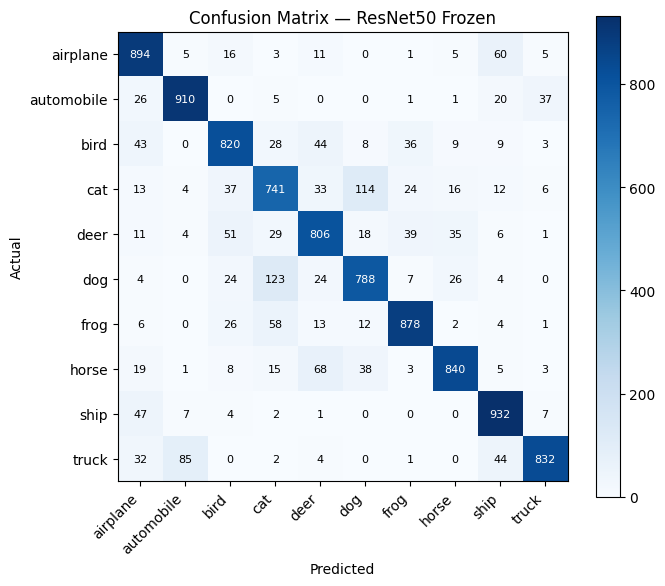

Epoch 1/6
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 49ms/step - accuracy: 0.8492 - loss: 0.4407 - val_accuracy: 0.8652 - val_loss: 0.3849
Epoch 2/6
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8672 - loss: 0.3858 - val_accuracy: 0.8710 - val_loss: 0.3673
Epoch 3/6
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8791 - loss: 0.3495 - val_accuracy: 0.8732 - val_loss: 0.3572
Epoch 4/6
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8896 - loss: 0.3196 - val_accuracy: 0.8750 - val_loss: 0.3505


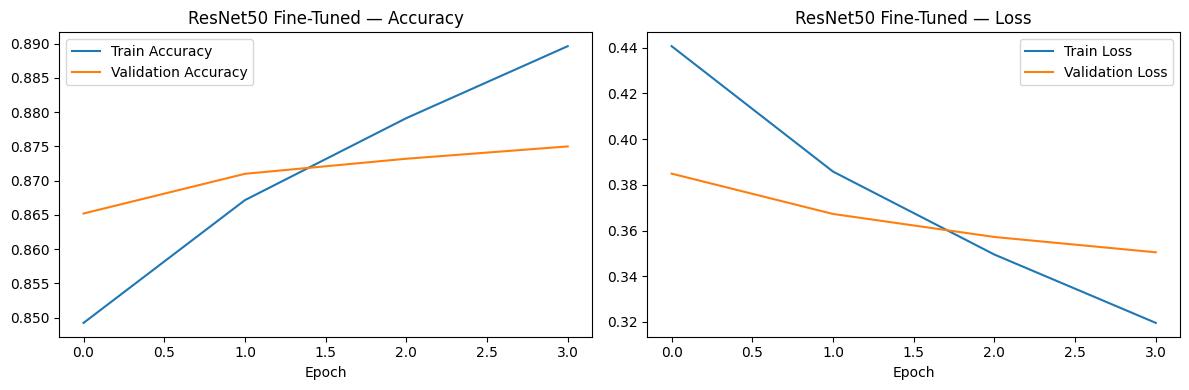


=== ResNet50 Fine-Tuned: Test Set Evaluation ===
Accuracy : 0.8614
Precision: 0.8614
Recall   : 0.8614
F1-score : 0.8613

Classification Report:
               precision    recall  f1-score   support

    airplane       0.85      0.88      0.87      1000
  automobile       0.92      0.90      0.91      1000
        bird       0.85      0.83      0.84      1000
         cat       0.77      0.76      0.76      1000
        deer       0.83      0.83      0.83      1000
         dog       0.82      0.82      0.82      1000
        frog       0.88      0.91      0.89      1000
       horse       0.90      0.88      0.89      1000
        ship       0.91      0.91      0.91      1000
       truck       0.90      0.90      0.90      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



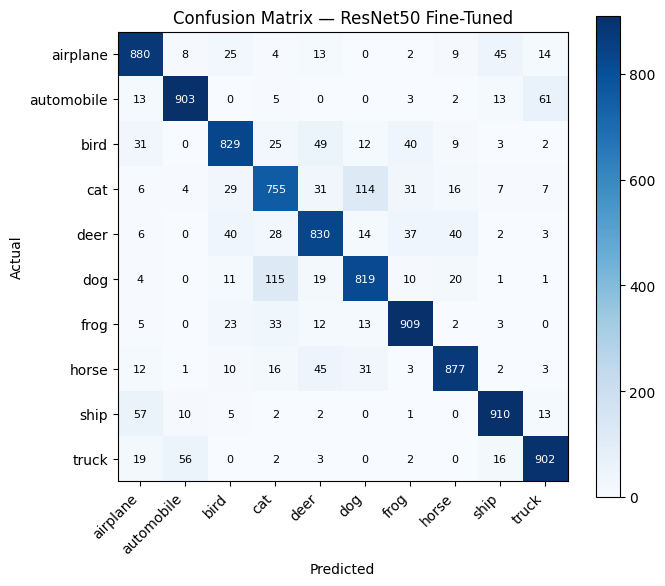

In [15]:

resnet_model, resnet_base, resnet_preprocess = build_transfer_model("ResNet50", IMG_SIZE)
compile_model(resnet_model, optimizer="adam", lr=CONFIG["LR_FROZEN"])

ds_train_res = make_tl_ds(x_train, y_train, resnet_preprocess, IMG_SIZE, training=True)
ds_val_res   = make_tl_ds(x_val, y_val, resnet_preprocess, IMG_SIZE, training=False)
ds_test_res  = make_tl_ds(x_test, y_test, resnet_preprocess, IMG_SIZE, training=False)

hist_res_frozen, t_res_frozen = train_model(resnet_model, ds_train_res, ds_val_res,
                                             epochs=CONFIG["EPOCHS_FROZEN"], callbacks=[early_stop])
plot_history(hist_res_frozen, title="ResNet50 Frozen")
res_resnet_frozen = evaluate_model(resnet_model, ds_test_res, y_test, title="ResNet50 Frozen")
res_resnet_frozen["train_time_sec"] = t_res_frozen

# Fine-tune
unfreeze_last_block(resnet_base, num_layers=10)
compile_model(resnet_model, optimizer="adam", lr=CONFIG["LR_FINETUNE"])
hist_res_ft, t_res_ft = train_model(resnet_model, ds_train_res, ds_val_res,
                                     epochs=CONFIG["EPOCHS_FINETUNE"], callbacks=[early_stop])
plot_history(hist_res_ft, title="ResNet50 Fine-Tuned")
res_resnet_ft = evaluate_model(resnet_model, ds_test_res, y_test, title="ResNet50 Fine-Tuned")
res_resnet_ft["train_time_sec"] = t_res_ft + t_res_frozen


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.7066 - loss: 1.0606 - val_accuracy: 0.8112 - val_loss: 0.5592
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7949 - loss: 0.6034 - val_accuracy: 0.8272 - val_loss: 0.5151
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8173 - loss: 0.5312 - val_accuracy: 0.8348 - val_loss: 0.4893
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8334 - loss: 0.4851 - val_accuracy: 0.8396 - val_loss: 0.4998
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8399 - loss: 0.4584 - val_accuracy: 0.8414 - val_loss: 0.4741

=== VGG16 [ADAM]: Test Set Evaluation ===
Accuracy : 0.8279
Precision: 0.8285
Recall   : 0.8279
F1-score : 0.8278

Classification Report:
               precision    recall  f1-score   support

    airplane       0.87      0.82      0.85      1000
  automobile       0.89      0.91      0.90      1000
        bird       0.80      0.78      0.79      100

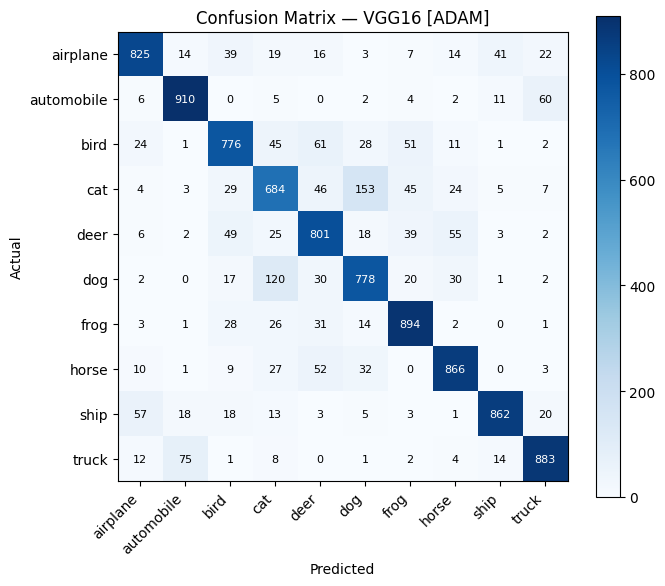

Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.6773 - loss: 1.1049 - val_accuracy: 0.7796 - val_loss: 0.6765
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7410 - loss: 0.8339 - val_accuracy: 0.8036 - val_loss: 0.6380
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7580 - loss: 0.7779 - val_accuracy: 0.8010 - val_loss: 0.6163
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7719 - loss: 0.7366 - val_accuracy: 0.7936 - val_loss: 0.6423
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7798 - loss: 0.7092 - val_accuracy: 0.8146 - val_loss: 0.6003

=== VGG16 [SGD]: Test Set Evaluation ===
Accuracy : 0.8079
Precision: 0.8151
Recall   : 0.8079
F1-score : 0.8079

Classification Report:
               precision    recall  f1-score   support

    airplane       0.79      0.88      0.83      1000
  automobile       0.85      0.91      0.88      1000
        bird       0.87      0.70      0.78      1000

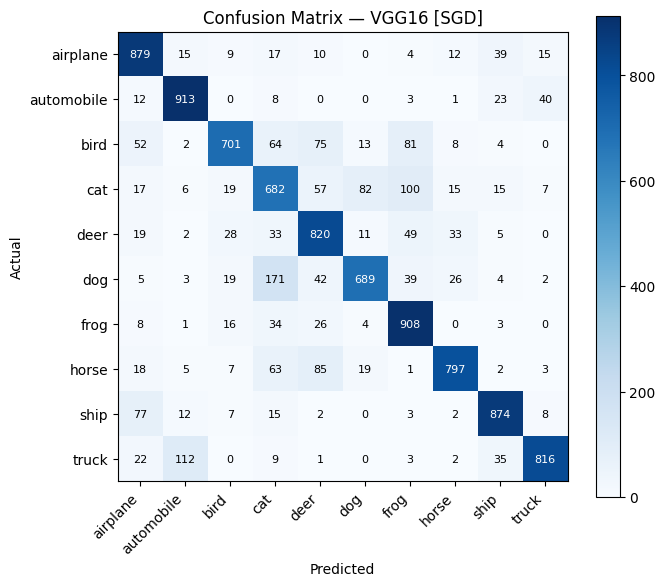

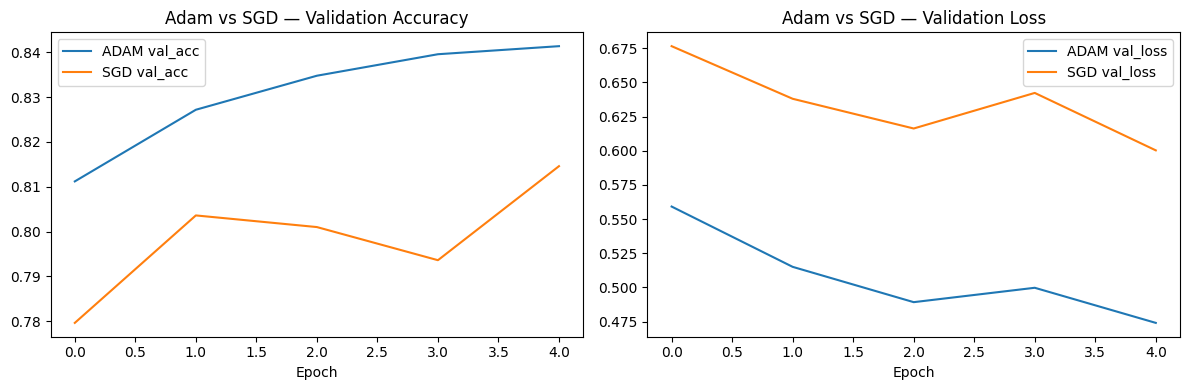

,Optimizer,Test Accuracy (%),F1-score,Time (s)
0,VGG16 [ADAM],82.79,0.8278,89.0
1,VGG16 [SGD],80.79,0.8079,88.1


In [16]:

optimizer_results = []
optimizer_histories = {}

for opt_name, lr in [("adam", CONFIG["LR_FROZEN"]), ("sgd", 1e-2)]:
    m, _, _ = build_transfer_model("VGG16", IMG_SIZE)
    compile_model(m, optimizer=opt_name, lr=lr)
    hist, elapsed = train_model(m, ds_train_vgg, ds_val_vgg,
                                 epochs=CONFIG["EPOCHS_OPTIM_COMPARE"])
    optimizer_histories[opt_name] = hist
    res = evaluate_model(m, ds_test_vgg, y_test, title=f"VGG16 [{opt_name.upper()}]")
    res["train_time_sec"] = elapsed
    optimizer_results.append(res)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for opt_name, hist in optimizer_histories.items():
    axes[0].plot(hist.history["val_accuracy"], label=f"{opt_name.upper()} val_acc")
    axes[1].plot(hist.history["val_loss"], label=f"{opt_name.upper()} val_loss")
axes[0].set_title("Adam vs SGD — Validation Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Adam vs SGD — Validation Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig("fig_adam_vs_sgd.png", dpi=120)
plt.show()

pd.DataFrame([{"Optimizer": r["model"], "Test Accuracy (%)": round(r["accuracy"]*100, 2),
               "F1-score": round(r["f1"], 4), "Time (s)": round(r["train_time_sec"], 1)}
              for r in optimizer_results])


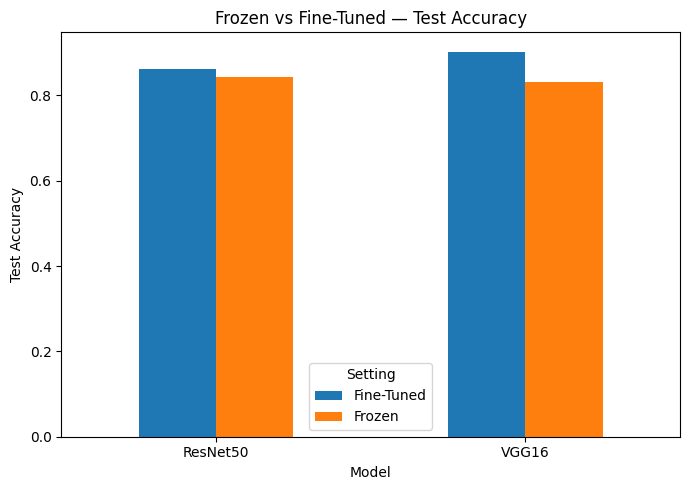

,Model,Setting,Accuracy
0,VGG16,Frozen,0.8310
1,VGG16,Fine-Tuned,0.9026
2,ResNet50,Frozen,0.8441
3,ResNet50,Fine-Tuned,0.8614


In [17]:

compare_df = pd.DataFrame([
    {"Model": "VGG16",    "Setting": "Frozen",     "Accuracy": res_vgg_frozen["accuracy"]},
    {"Model": "VGG16",    "Setting": "Fine-Tuned",  "Accuracy": res_vgg_ft["accuracy"]},
    {"Model": "ResNet50", "Setting": "Frozen",      "Accuracy": res_resnet_frozen["accuracy"]},
    {"Model": "ResNet50", "Setting": "Fine-Tuned",  "Accuracy": res_resnet_ft["accuracy"]},
])

pivot = compare_df.pivot(index="Model", columns="Setting", values="Accuracy")
ax = pivot.plot(kind="bar", figsize=(7, 5), rot=0)
ax.set_ylabel("Test Accuracy")
ax.set_title("Frozen vs Fine-Tuned — Test Accuracy")
plt.tight_layout()
plt.savefig("fig_frozen_vs_finetuned.png", dpi=120)
plt.show()

compare_df


In [18]:

hparam_grid = [
    {"lr": 1e-3, "dense_units": 128, "frozen": "All"},
    {"lr": 1e-3, "dense_units": 256, "frozen": "All"},
    {"lr": 1e-4, "dense_units": 256, "frozen": "Partial"},
]

hparam_results = []
for cfg in hparam_grid:
    m, base, _ = build_transfer_model("VGG16", IMG_SIZE, dense_units=cfg["dense_units"])
    if cfg["frozen"] == "Partial":
        unfreeze_last_block(base, num_layers=4)
    compile_model(m, optimizer="adam", lr=cfg["lr"])
    hist, elapsed = train_model(m, ds_train_vgg, ds_val_vgg, epochs=CONFIG["EPOCHS_HPARAM_SEARCH"])
    val_acc = hist.history["val_accuracy"][-1]
    hparam_results.append({**cfg, "val_accuracy": round(val_acc, 4), "time_sec": round(elapsed, 1)})

pd.DataFrame(hparam_results)


Epoch 1/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.6603 - loss: 1.2126 - val_accuracy: 0.7952 - val_loss: 0.6091
Epoch 2/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7698 - loss: 0.6832 - val_accuracy: 0.8128 - val_loss: 0.5355
Epoch 3/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7942 - loss: 0.6039 - val_accuracy: 0.8202 - val_loss: 0.5118
Epoch 4/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8092 - loss: 0.5576 - val_accuracy: 0.8330 - val_loss: 0.4884
Epoch 1/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.7010 - loss: 1.0667 - val_accuracy: 0.8088 - val_loss: 0.5637
Epoch 2/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7943 - loss: 0.6105 - val_accuracy: 0.8246 - val_loss: 0.5189
Epoch 3/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8156 - loss: 0.5442 - val_accuracy: 0.8320 - val_loss: 0.4965
Epoch 4/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8311 - loss: 0.4919 - val_accu

,lr,dense_units,frozen,val_accuracy,time_sec
0,0.0010,128,All,0.8330,73.4
1,0.0010,256,All,0.8402,72.8
2,0.0001,256,Partial,0.9098,89.0


In [19]:

final_rows = []
for r in baseline_results:
    final_rows.append({"Model": r["model"], "Parameters": r["params"],
                        "Test Accuracy (%)": round(r["accuracy"]*100, 2),
                        "Precision": round(r["precision"], 4), "Recall": round(r["recall"], 4),
                        "F1-score": round(r["f1"], 4), "Training Time (s)": round(r["train_time_sec"], 1)})

for r in (res_vgg_frozen, res_vgg_ft, res_resnet_frozen, res_resnet_ft):
    final_rows.append({"Model": r["model"], "Parameters": None,
                        "Test Accuracy (%)": round(r["accuracy"]*100, 2),
                        "Precision": round(r["precision"], 4), "Recall": round(r["recall"], 4),
                        "F1-score": round(r["f1"], 4), "Training Time (s)": round(r["train_time_sec"], 1)})

final_table = pd.DataFrame(final_rows)
final_table.to_csv("final_comparison_table.csv", index=False)
final_table


,Model,Parameters,Test Accuracy (%),Precision,Recall,F1-score,Training Time (s)
0,LeNet5,83126.0,54.26,0.5481,0.5426,0.5403,232.8
1,AlexNetMini,6976842.0,75.26,0.7575,0.7526,0.7486,306.1
2,ResNetMini,681226.0,47.26,0.5552,0.4726,0.4317,141.1
3,VGG16 Frozen,NaN,83.10,0.8323,0.8310,0.8306,141.1
4,VGG16 Fine-Tuned,NaN,90.26,0.9035,0.9026,0.9028,290.3
5,ResNet50 Frozen,NaN,84.41,0.8455,0.8441,0.8440,91.1
6,ResNet50 Fine-Tuned,NaN,86.14,0.8614,0.8614,0.8613,194.3
